### **Experiments for neural network non-convex optimization problem**

In this notebook, we will use a trained gradient descent model with adaptive learning rate to optimize LeNet-5 on the MNIST task.

In [3]:
import gymnasium as gym
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import src.gymnasium_envs.nn_optimization_env

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize, VecFrameStack

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import TensorDataset, DataLoader

import copy
import itertools

from src.nn_models.lenet import LeNet

seed = 42
max_iterations = 10000
    

In [4]:
def run_standard_optimizers(seed, train_ds, iteration_count=10000):
    results = {}
    base_nn_model = LeNet(seed=seed)
    initial_state = copy.deepcopy(base_nn_model.state_dict())
    
    experiments = {
        'SGD': {'class': optim.SGD, 'params': {'lr': 0.001}},
        'Adam': {'class': optim.Adam, 'params': {'lr': 0.001}}
    }
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    for name, config in experiments.items():
        print(f"Starting optimization with {name}")
        nn_model = LeNet(seed=seed)
        nn_model.load_state_dict(initial_state)
        nn_model.to(device)
        
        optimizer = config['class'](nn_model.parameters(), **config['params'])
        criterion = nn.CrossEntropyLoss()
        
        g = torch.Generator()
        g.manual_seed(seed)
        train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, generator=g)
        train_loader = itertools.cycle(train_loader)
        
        losses = []
        for i in range(iteration_count):
            inputs, labels = next(train_loader)
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = nn_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            loss_value = loss.item()
            losses.append(loss_value)
            if i % 100 == 0:
                print(f"Method: {name} | Iteration: {i} | Loss: {loss_value}")
            optimizer.step()
        results[name] = losses
    return results

def run_rl_optimizer(seed, rl_model_path, norm_stats_path, env_kwargs=None):
    if env_kwargs is None:
        env_kwargs = {"dataset_name": "MNIST", "max_iterations": 10000}
    
    env = make_vec_env(
        "nn_optimization_env/NeuralNetworkOptimization-v1",
        n_envs=1,
        seed=seed,
        env_kwargs=env_kwargs
    )
    env = VecNormalize.load(norm_stats_path, env)
    env.training = False
    env.norm_reward = False
    
    model = PPO.load(rl_model_path, env=env, seed=seed)
    obs = env.reset()
    losses = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, info = env.step(action)
        losses.append(info[0]['loss'])
        done = terminated
    env.close()
    return losses

def get_mnist_datasets():
    train_dataset = datasets.MNIST(root='./data', train=True, download=True)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True)
    
    X_train = train_dataset.data.unsqueeze(1).float() / 255.0
    y_train = train_dataset.targets.long()
    X_test = test_dataset.data.unsqueeze(1).float() / 255.0
    y_test = test_dataset.targets.long()
    
    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)
    return train_ds, test_ds

def plot_comparison(results_dict, step=500):
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    marker_types = ['o', 's', '^', 'D', 'X', 'v', '*']
    line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 10))]
    
    for i, (name, values) in enumerate(results_dict.items()):
        data = np.array(values)
        sampled_values = data[::step]
        iterations = np.arange(0, len(data), step)
        
        plt.plot(iterations, sampled_values,
                 label=name,
                 marker=marker_types[i % len(marker_types)],
                 linestyle=line_styles[i % len(line_styles)],
                 markersize=8,
                 linewidth=2.5,
                 alpha=0.9)
    
    plt.yscale('log')
    plt.xlabel('Шаг оптимизации', fontsize=16)
    plt.ylabel('Значение функции потерь (log)', fontsize=16)
    plt.legend(loc='best', fontsize=14)
    plt.show()

In [5]:
train_ds, _ = get_mnist_datasets()

### 1. Convergence AdaRL vs. SGD vs. ADAM

c:\Users\Lolik\Documents\GitHub\Reinforcement-learning-for-Gradient-descent\venv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes (['ansi']).
  logger.warn(


Starting optimization with SGD
Method: SGD | Iteration: 0 | Loss: 2.4921112060546875
Method: SGD | Iteration: 100 | Loss: 2.386749029159546
Method: SGD | Iteration: 200 | Loss: 2.40160870552063
Method: SGD | Iteration: 300 | Loss: 2.300401210784912
Method: SGD | Iteration: 400 | Loss: 2.335550308227539
Method: SGD | Iteration: 500 | Loss: 2.3073501586914062
Method: SGD | Iteration: 600 | Loss: 2.327575922012329
Method: SGD | Iteration: 700 | Loss: 2.3010387420654297
Method: SGD | Iteration: 800 | Loss: 2.3116796016693115
Method: SGD | Iteration: 900 | Loss: 2.306871175765991
Method: SGD | Iteration: 1000 | Loss: 2.2953855991363525
Method: SGD | Iteration: 1100 | Loss: 2.3054885864257812
Method: SGD | Iteration: 1200 | Loss: 2.301679849624634
Method: SGD | Iteration: 1300 | Loss: 2.30283522605896
Method: SGD | Iteration: 1400 | Loss: 2.2979273796081543
Method: SGD | Iteration: 1500 | Loss: 2.301229476928711
Method: SGD | Iteration: 1600 | Loss: 2.2992899417877197
Method: SGD | Iteration

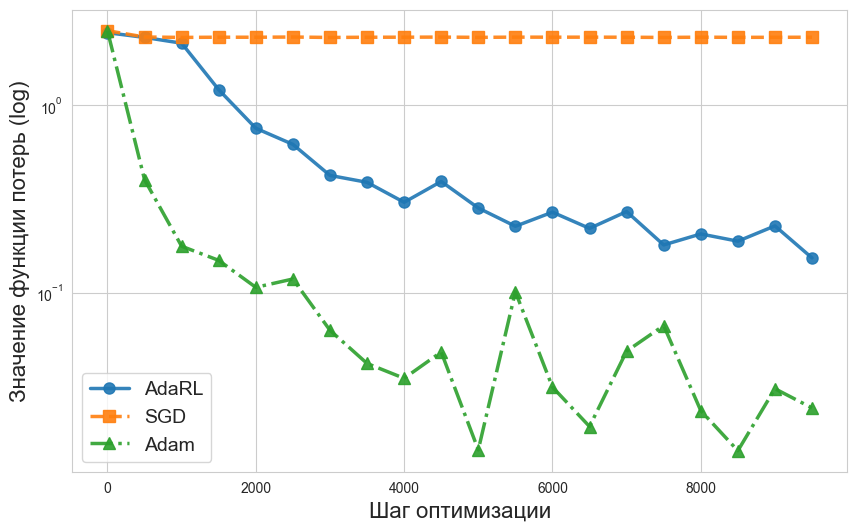

In [5]:
rl_losses = run_rl_optimizer(
    seed=seed,
    rl_model_path="../models/less_iters_nn",
    norm_stats_path="../models/less_iters_nn_vec_normalize.pkl",
    env_kwargs={"dataset_name": "MNIST", "max_iterations": max_iterations}
)

standard_results = run_standard_optimizers(seed, train_ds, max_iterations)
    
all_results = {"AdaRL": rl_losses, **standard_results}
plot_comparison(all_results, step=500)

### 2. Convergence AdaRL (more steps for episode) vs. SGD vs. ADAM

c:\Users\Lolik\Documents\GitHub\Reinforcement-learning-for-Gradient-descent\venv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes (['ansi']).
  logger.warn(


Starting optimization with SGD
Method: SGD | Iteration: 0 | Loss: 2.4921112060546875
Method: SGD | Iteration: 100 | Loss: 2.386749029159546
Method: SGD | Iteration: 200 | Loss: 2.40160870552063
Method: SGD | Iteration: 300 | Loss: 2.300401210784912
Method: SGD | Iteration: 400 | Loss: 2.335550308227539
Method: SGD | Iteration: 500 | Loss: 2.3073501586914062
Method: SGD | Iteration: 600 | Loss: 2.327575922012329
Method: SGD | Iteration: 700 | Loss: 2.3010387420654297
Method: SGD | Iteration: 800 | Loss: 2.3116796016693115
Method: SGD | Iteration: 900 | Loss: 2.306871175765991
Method: SGD | Iteration: 1000 | Loss: 2.2953855991363525
Method: SGD | Iteration: 1100 | Loss: 2.3054885864257812
Method: SGD | Iteration: 1200 | Loss: 2.301679849624634
Method: SGD | Iteration: 1300 | Loss: 2.30283522605896
Method: SGD | Iteration: 1400 | Loss: 2.2979273796081543
Method: SGD | Iteration: 1500 | Loss: 2.301229476928711
Method: SGD | Iteration: 1600 | Loss: 2.2992899417877197
Method: SGD | Iteration

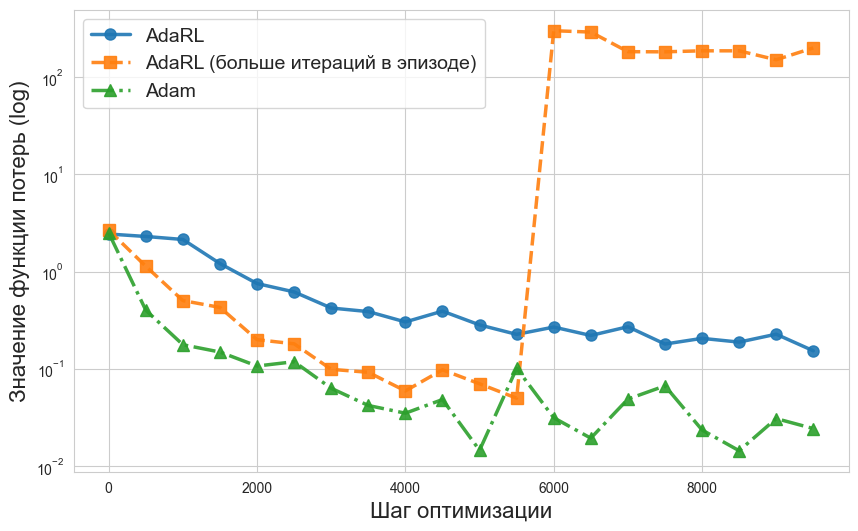

In [6]:
rl_losses1 = run_rl_optimizer(
    seed=seed,
    rl_model_path="../models/less_iters_nn",
    norm_stats_path="../models/less_iters_nn_vec_normalize.pkl",
    env_kwargs={"dataset_name": "MNIST", "max_iterations": max_iterations}
)

rl_losses2 = run_rl_optimizer(
    seed=seed,
    rl_model_path="../models/nn",
    norm_stats_path="../models/nn_vec_normalize.pkl",
    env_kwargs={"dataset_name": "MNIST", "max_iterations": max_iterations}
)

standard_results = run_standard_optimizers(seed, train_ds, max_iterations)
    
all_results = {"AdaRL": rl_losses1, "AdaRL (больше итераций в эпизоде)" : rl_losses2, "Adam" : standard_results["Adam"]}
plot_comparison(all_results, step=500)

In [ ]:
rl_losses1 = run_rl_optimizer(
    seed=seed,
    rl_model_path="../models/less_iters_nn",
    norm_stats_path="../models/less_iters_nn_vec_normalize.pkl",
    env_kwargs={"dataset_name": "MNIST", "max_iterations": max_iterations}
)

rl_losses2 = run_rl_optimizer(
    seed=seed,
    rl_model_path="../models/learn_betas_nn",
    norm_stats_path="../models/learn_betas_nn_vec_normalize.pkl",
    env_kwargs={"dataset_name": "MNIST", "max_iterations": max_iterations, "learn_betas" : True}
)

standard_results = run_standard_optimizers(seed, train_ds, max_iterations)
    
all_results = {"AdaRL": rl_losses1, "AdaRL (увеличение пространства действий)" : rl_losses2, "Adam" : standard_results["Adam"]}
plot_comparison(all_results, step=500)